<a href="https://colab.research.google.com/github/ivan-block/ANN/blob/main/heartdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, recall_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.optimizers import Adam
import numpy as np
import seaborn as sns

In [27]:
heart_data = pd.read_csv("Heartdata.csv")

heart_data.head(20)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
5,90.0,1,47,0,40,1,204000.00,2.1,132,1,1,8,1
6,75.0,1,246,0,15,0,127000.00,1.2,137,1,0,10,1
7,60.0,1,315,1,60,0,454000.00,1.1,131,1,1,10,1
8,65.0,0,157,0,65,0,263358.03,1.5,138,0,0,10,1
9,80.0,1,123,0,35,1,388000.00,9.4,133,1,1,10,1


In [28]:
heart_data.tail(20)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
279,55.0,0,84,1,38,0,451000.00,1.3,136,0,0,246,0
280,70.0,0,2695,1,40,0,241000.00,1.0,137,1,0,247,0
281,70.0,0,582,0,40,0,51000.00,2.7,136,1,1,250,0
282,42.0,0,64,0,30,0,215000.00,3.8,128,1,1,250,0
283,65.0,0,1688,0,38,0,263358.03,1.1,138,1,1,250,0
284,50.0,1,54,0,40,0,279000.00,0.8,141,1,0,250,0
285,55.0,1,170,1,40,0,336000.00,1.2,135,1,0,250,0
286,60.0,0,253,0,35,0,279000.00,1.7,140,1,0,250,0
287,45.0,0,582,1,55,0,543000.00,1.0,132,0,0,250,0
288,65.0,0,892,1,35,0,263358.03,1.1,142,0,0,256,0


In [29]:
heart_data.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


In [30]:
X = heart_data.drop('DEATH_EVENT', axis=1)
y = heart_data['DEATH_EVENT']

print(X.shape)
print(y.shape)

(299, 12)
(299,)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [32]:
scalar = StandardScaler()

X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


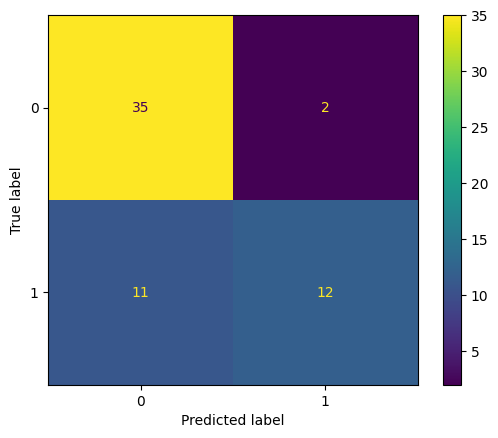

In [38]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100),
    activation='relu',
    solver='adam',
    random_state = 0
)
mlp.fit(X_train, y_train)
ymlp_predict = (mlp.predict(X_test))
ymlp_predict = np.round(ymlp_predict).astype(int)

cm = confusion_matrix(y_test, ymlp_predict)
ConfusionMatrixDisplay(cm).plot()


In [51]:
print('Accuracy Score: {:.4f}'.format(accuracy_score(y_test, ymlp_predict)))
print('F1 Score: {:.4f}'.format(f1_score(y_test, ymlp_predict)))
print('Recall Score: {:.4f}'.format(recall_score(y_test, ymlp_predict)))
print('Precision Score: {:.4f}'.format(precision_score(y_test, ymlp_predict)))

print(classification_report(y_test, ymlp_predict))

Accuracy Score: 0.7833
F1 Score: 0.6486
Recall Score: 0.5217
Precision Score: 0.8571
              precision    recall  f1-score   support

           0       0.76      0.95      0.84        37
           1       0.86      0.52      0.65        23

    accuracy                           0.78        60
   macro avg       0.81      0.73      0.75        60
weighted avg       0.80      0.78      0.77        60



In [55]:
classifier = Sequential()
classifier.add(Dense(units=6, activation = 'relu', input_dim =12))
classifier.add(Dense(units=6, activation = 'relu'))
classifier.add(Dense(units=1, activation = 'sigmoid'))
classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
classifier.fit(X_train, y_train, validation_split= 0.1, epochs = 100)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.6299 - loss: 0.7366 - val_accuracy: 0.6250 - val_loss: 0.7732
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6405 - loss: 0.7564 - val_accuracy: 0.6667 - val_loss: 0.7649
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6625 - loss: 0.7379 - val_accuracy: 0.6667 - val_loss: 0.7566
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6996 - loss: 0.7194 - val_accuracy: 0.6667 - val_loss: 0.7487
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6982 - loss: 0.7136 - val_accuracy: 0.6667 - val_loss: 0.7410
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7182 - loss: 0.6951 - val_accuracy: 0.6667 - val_loss: 0.7335
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6862 - loss: 0.6958 - val_accuracy: 0.7083 - val_loss: 0.7260
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6873 - loss: 0.6971 - val_accuracy: 0.7083 - val_loss:

In [59]:
y_pred = classifier.predict(X_test)
print(y_pred.dtype)

y_pred = np.round(y_pred).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
float32


In [63]:
print('Accuracy Score: {:.4f}'.format(accuracy_score(y_test, y_pred)))
print('Precision Score: {:.4f}'.format(precision_score(y_test, y_pred)))
print('Recall Score: {:.4f}'.format(recall_score(y_test, y_pred)))
print('F1 Score: {:.4f}'.format(f1_score(y_test, y_pred)))
print(classification_report(y_test, y_pred))

Accuracy Score: 0.7667
Precision Score: 0.8462
Recall Score: 0.4783
F1 Score: 0.6111
              precision    recall  f1-score   support

           0       0.74      0.95      0.83        37
           1       0.85      0.48      0.61        23

    accuracy                           0.77        60
   macro avg       0.80      0.71      0.72        60
weighted avg       0.78      0.77      0.75        60



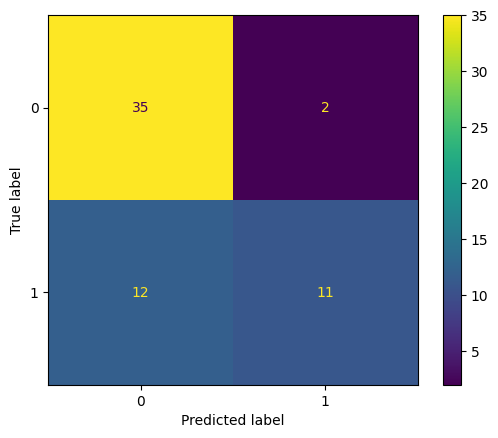

In [64]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()